# Gradient Descent(경사 하강법)

* 머신 러닝의 목적은 손실(비용) 함수를 최소로 만드는 모델 파라미터(w0, w1, ...)들을 찾는 것.
* 회귀 문제에서는 비용 함수는 MSE(w)
  * w에 대한 2차 함수의 최솟값의 위치를 찾는 문제.
* 경사 하강법: 함수의 최솟값의 위치를 찾는 알고리즘의 하나.
  * 함수의 임의의 위치에서 시작.
  * 그 위치에서 접선의 기울기(gradient)를 계산.
  * gradient의 절댓값이 줄어드는 방향으로 w 값을 약간 변경.
  * 위의 과정을 충분히 반복하면 함수가 최소가 되는 위치 w를 찾을 수 있다.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt


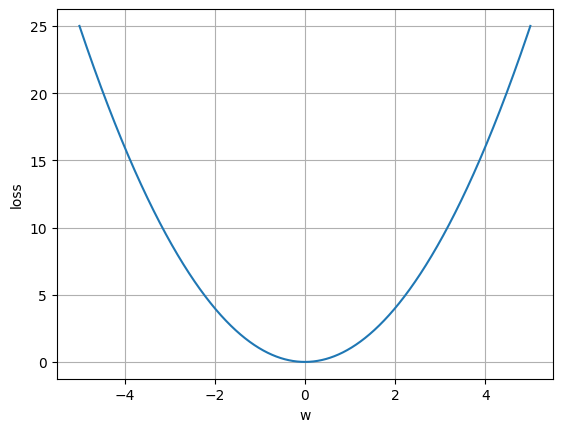

In [4]:
w = np.arange(-5,5,0.0001)
fn = w **2

plt.plot(w, fn)
plt.grid()
plt.xlabel('w')
plt.ylabel('loss')
plt.show()

In [7]:
# 임의의 w 위치를 선택
w_init = -4

# 선택한 위치(w_init)에서 함수의 접선의 기울기(gradient)를 계산
gradient =2* w_init

# 처음 위치에서 기울기의 반대 방향으로 약간 이동
w_next = w_init - gradient *0.1

w_next

# 음수는 + 주고, 양수는 - 준다

-3.2

In [8]:
# 이동한 위치에서 다시 시작 한다.
w_init = w_next

# 다시 시작하는 위치에서 함수의 접선의 기울기 계산
gradient = 2* w_init

# 기울기의 반대 방향으로 약간 이동시키기
w_next = w_init - gradient*0.1

w_next

# 0을향해가는중(최솟값) =gradient descent

-2.56

In [44]:
def gradient_descent(learning_rate=0.1, max_iter=50, tolerance=0.0001): # learning_rate: 기울기에 곱할 값, max_iter: 최대반복횟수
                                                                        # 초기 값 max=50 to=0.0001
  # f(w) =w^2 2차 함수를 시각화
  w = np.arange(-5,5,0.0001)
  fn = w ** 2
  plt.plot(w,fn,color='DarkGrey')

  # 임의의 점에서 시작
  w_init=-4
  # 사작점의 위치를 점으로 표시
  plt.scatter(w_init, w_init**2,label='0')

  convergence = False
  for n in range(max_iter):

    # 시작점의 위치에서 gradient를 계산
    gradient = 2 * w_init # f(w) = w^2 일 때, gradient = df/dw = 2 * w

    # gradient의 반대 방향으로 약간 이동
    w_next = w_init - gradient * learning_rate

    # 이동한 점의 위치를 점으로 표시
    plt.scatter(w_next, w_next**2, label=f'{n+1}')

    # 반복을 계속할 지, 아니면 멈출 지를 결정. 하는 if
    # 이동한 위치 w_next와 이동하기 전 위치 w_init 사이의 거리가
    # tolerance(기본값 0.0001)보다 작으면 반복을 멈춤.
    if np.abs(w_next - w_init) < tolerance: # abs는 절댓값계산 이동위치-첫번째위치
        convergence=True
        break # 반복문을 멈춤

    w_init = w_next # 다음 반복(iteration)을 시작하기 전에 이동할 위치를 시작위치로 옮긴다.
  print('함수가 최솟값인 w 위치는 =',w_next)
  if convergence == False:
    print('ConvergenceWarning: 정확한 최솟값의 위치가 아닐 수 있습니다.')
  # TODO
  plt.legend()
  plt.grid()
  # plt.xlim(-0.002,0.002)
  plt.xlim(-100,100)
  plt.ylim(-5,700)
  plt.xlabel('w')
  plt.ylabel('loss')
  plt.show()

함수가 최솟값인 w 위치는 = -0.0003402823669209386


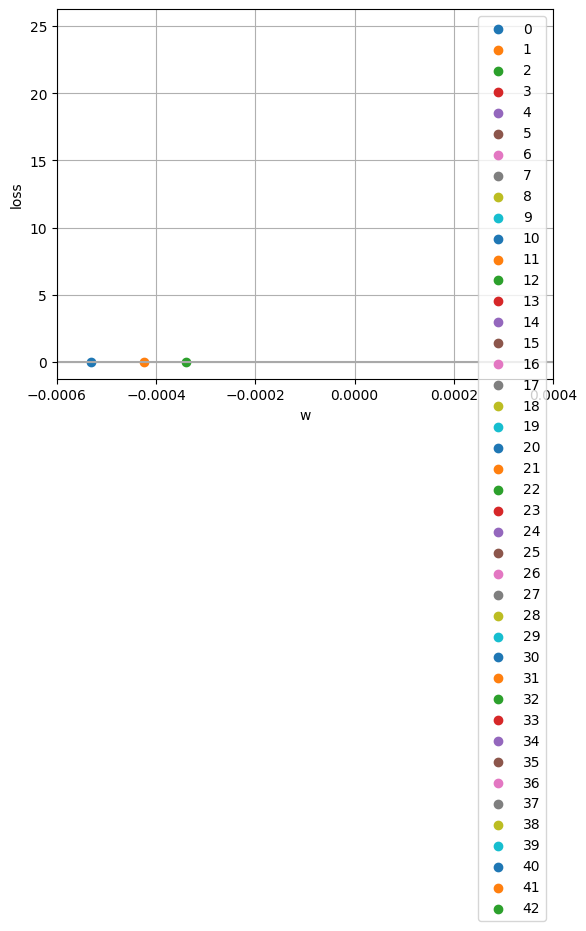

In [24]:
gradient_descent()

함수가 최솟값인 w 위치는 = -3.653754093327259e-05


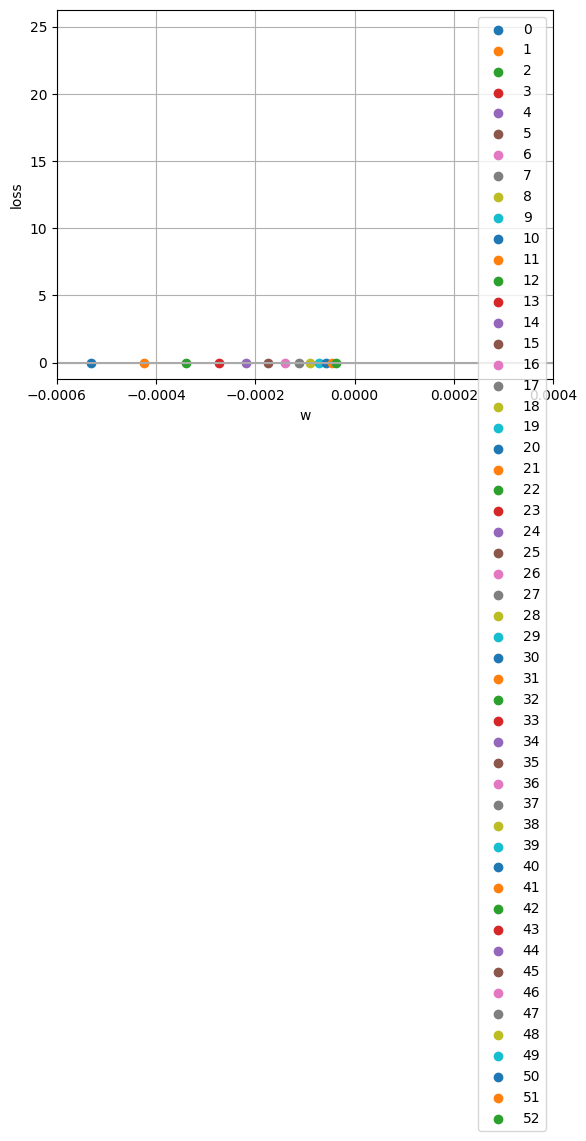

In [25]:
gradient_descent(max_iter=1000, tolerance=0.00001)

함수가 최솟값인 w 위치는 = -0.4294967296000001


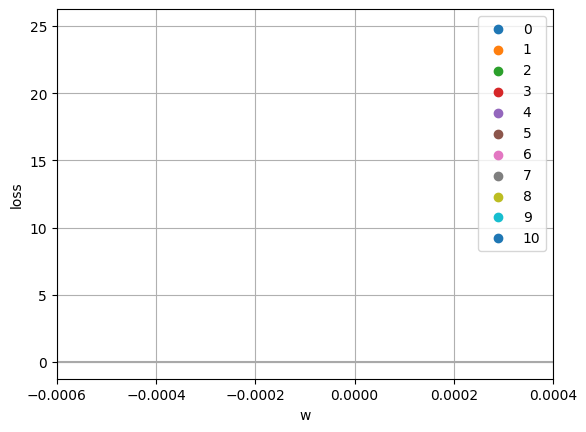

In [26]:
gradient_descent(max_iter=10) # 진짜최솟값은아님

함수가 최솟값인 w 위치는 = -0.0001462463376025189


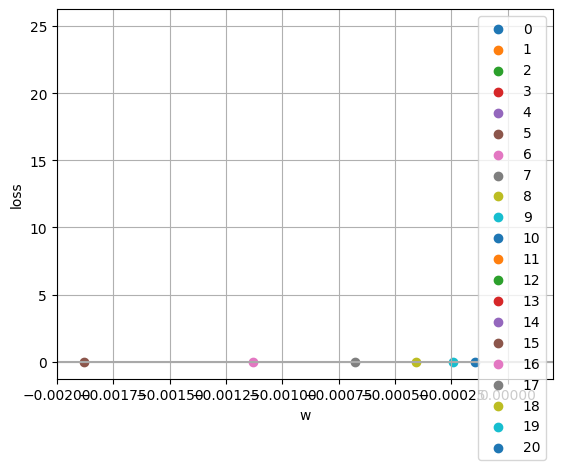

In [33]:
gradient_descent(learning_rate=0.2)

함수가 최솟값인 w 위치는 = 3.158920892214423e-05


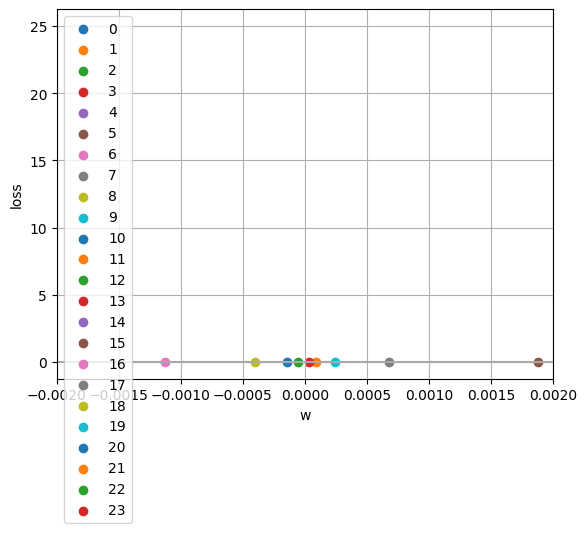

In [36]:
gradient_descent(learning_rate=0.8)

함수가 최솟값인 w 위치는 = -36401.752600008855


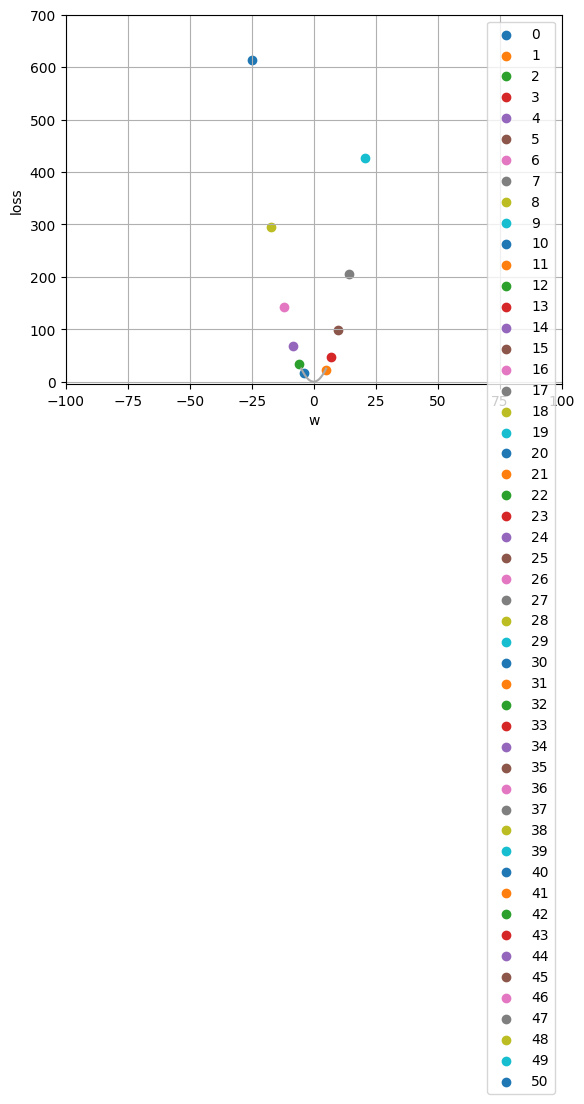

In [45]:
gradient_descent(learning_rate=1.1) # 발산 divergence

**학습률(learning rate)** 하이퍼 파라미터

* 학습률이 작은 경우에는 최솟값을 향해서 천천히 움직임.
* 학습률이 큰 경우에는 최솟값을 향해서 빠르게 또는 불안정하게 움직임.
* 학습률이 너무 작으면 최대 반복 횟수(max_iter) 안에서 최솟값의 위치로 수렴(convergence)하지 못할 수도 있다.
  * 학습률을 더 크게 만듦.
  * 최대 반복 횟수(max_iter)를 늘려줌.
  * 수렴 기준(tolerance)을 더 크게 만듦.
* 학습률이 너무 크면 수렴하지 못하고 발산(divergence)하는 경우가 생긴다.  
  * 학습률을 줄여야 함.
* 머신 러닝 알고리즘들 중에서는 처음에는 학습률을 크게 하고, 반복이 진행될 때마다 학습률을 점진적으로 줄여 나가는 방식으로 데이터를 학습하는 알고리즘도 있음.  

# SGDRegressor

확률적 경사 하강법(Stocahastic Gradient Descent) 알고리즘을 사용해서 손실 함수가 최소가 되는 모델 파라미터들을 찾고 수치를 예측하는 머신 러닝 모델.

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

In [49]:
file_path='https://bit.ly/fish_csv_data'

In [50]:
fish=pd.read_csv(file_path)

In [51]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [52]:
perch = fish[fish.Species=='Perch']

In [54]:
perch[:5]

,Species,Weight,Length,Diagonal,Height,Width
72,Perch,5.9,8.4,8.8,2.1120,1.4080
73,Perch,32.0,13.7,14.7,3.5280,1.9992
74,Perch,40.0,15.0,16.0,3.8240,2.4320
75,Perch,51.5,16.2,17.2,4.5924,2.6316
76,Perch,70.0,17.4,18.5,4.5880,2.9415


In [55]:
x = perch[['Length']].to_numpy() # 특성 배열
y=perch['Weight'].to_numpy() # 타겟 배열

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42) #훈련셋과 테스트셋에 비율은 어떤기준

In [68]:
sgd=SGDRegressor() #SGD 회귀 모델 생성

In [69]:
sgd.fit(X=x_train,y=y_train) #

SGDRegressor()

In [70]:
sgd.predict(X=x_train)

array([ 2.43542052e+08,  3.99528186e+07,  3.19888014e+08,  4.30165516e+08,
       -1.14765104e+09, -2.14533723e+08, -1.48696643e+09, -1.40213758e+09,
       -1.74145297e+09,  3.99528186e+07,  2.09610513e+08,  3.99528186e+07,
       -1.29704876e+08, -4.26605841e+08, -1.74145297e+09, -1.48696643e+09,
       -1.29704876e+08,  1.24781666e+08, -4.26605841e+08, -1.48696643e+09,
       -8.76198731e+08, -3.41776994e+08, -1.19006547e+09,  7.44032250e+08,
       -1.94273744e+07,  6.33754749e+08, -1.23247989e+09, -1.06282219e+09,
       -5.28400458e+08, -8.72904522e+07, -1.40213758e+09,  1.24781666e+08,
       -4.48760286e+07,  3.99528186e+07, -1.82628182e+09, -2.46160500e+06,
        2.94439360e+08, -1.23247989e+09,  3.99528186e+07, -2.65431031e+08,
       -1.65662413e+09, -1.02040777e+09])

In [71]:
sgd.score(x_train,y_train) # 훈련 셋 R2 score(결정계수)

-6523890939832.636

In [72]:
sgd.score(x_test,y_test) # 테스트 셋  결정계수

-7291806844225.414

훈련 셋의 샘플 개수가 너무 작아서 1,000번(max_iter) 반복하는 것으로는 최적의 값으로 수렴하지 못함.

해결 방법:
* 최대 반복 횟수(max_iter)를 늘려줌.
* 규제의 크기(alpha)를 줄임.
* 학습률(learning_rate, eta0, power_t)을 키움.

* SGDRegressor 사용
  * max_iter = 1_000_000_000
  * learning_rate = ['constant', 'invscaling', 'adpative']
  * eta0 = [0.01, 0.1, 0.3, 0.5, 1.0]: 초기 학습률.

In [86]:
max_iterations=1000000000 # 최대 반복횟수
learning_rates=['constant','invscaling','adaptive'] # 학습률 변경 방법
eta0s=[0.01,0.1,0.3,0.5,1.0] # 초기 학습률

for lr in learning_rates:
  for eta in eta0s:
    # sgd 회귀 모델을 생성
    sgd= SGDRegressor(max_iter=max_iterations,learning_rate=lr,eta0=eta, random_state=42)

    # 모델훈련
    sgd.fit(x_train,y_train)
    # 훈련 셋 결정계수
    train_score=sgd.score(x_train,y_train)
    # 테스트 셋 결정계수
    test_score=sgd.score(x_test,y_test)
    print(f'learning_rate={lr},eta0={eta}, train_r2={train_score:.3e},test_r2={test_score:.3e}')
    # 선생님


learning_rate=constant,eta0=0.01, train_r2=-4.248e+20,test_r2=-4.579e+20
learning_rate=constant,eta0=0.1, train_r2=-6.131e+22,test_r2=-6.601e+22
learning_rate=constant,eta0=0.3, train_r2=-5.317e+23,test_r2=-5.723e+23
learning_rate=constant,eta0=0.5, train_r2=-3.758e+23,test_r2=-4.056e+23
learning_rate=constant,eta0=1.0, train_r2=-5.958e+24,test_r2=-6.417e+24
learning_rate=invscaling,eta0=0.01, train_r2=-1.479e+13,test_r2=-1.650e+13
learning_rate=invscaling,eta0=0.1, train_r2=-8.941e+20,test_r2=-9.604e+20
learning_rate=invscaling,eta0=0.3, train_r2=-1.070e+21,test_r2=-1.143e+21
learning_rate=invscaling,eta0=0.5, train_r2=-5.037e+21,test_r2=-5.410e+21
learning_rate=invscaling,eta0=1.0, train_r2=-1.849e+22,test_r2=-1.988e+22
learning_rate=adaptive,eta0=0.01, train_r2=9.146e-01,test_r2=6.976e-01
learning_rate=adaptive,eta0=0.1, train_r2=9.200e-01,test_r2=8.681e-01
learning_rate=adaptive,eta0=0.3, train_r2=-4.953e+18,test_r2=-8.170e+18
learning_rate=adaptive,eta0=0.5, train_r2=-6.789e+18,te

In [85]:
def sgd_regressor(learning, eta,max_iter=1000000000):
    learning=['constant','invscaling','adaptive']
    eta=[0.01,0.1,0.3,0.5,1.0]
    vintr=[]
    vinte=[]
    for learning1 in learning:
      for eta1 in eta:
        sgd=SGDRegressor(learning_rate=learning1,eta0=eta1,max_iter=max_iter,random_state=42)
        sgd.fit(x_train,y_train)
        tr=sgd.score(x_train, y_train)
        te=sgd.score(x_test, y_test)
        vintr.append(tr)
        vinte.append(te)
        # print(f'---------{learning1}-----------')
        print(f'learning_rate={learning1},eta0={eta1}')
        print(f'훈련 세트 점수:{tr:.3f}')
        print(f'테스트 세트 점수:{te:.3f}')
    return vintr,vinte
#나

In [84]:
sgd_regressor()

learning_rate=constant,eta0=0.01
훈련 세트 점수:-82118563339699961856.000
테스트 세트 점수:-88255253714553667584.000
learning_rate=constant,eta0=0.1
훈련 세트 점수:-46968419898098838405120.000
테스트 세트 점수:-50543233328747475107840.000
learning_rate=constant,eta0=0.3
훈련 세트 점수:-199504533355357834051584.000
테스트 세트 점수:-215108490703805679140864.000
learning_rate=constant,eta0=0.5
훈련 세트 점수:-1050007989565313614086144.000
테스트 세트 점수:-1131924410615435263737856.000
learning_rate=constant,eta0=1.0
훈련 세트 점수:-8028124242307857994743808.000
테스트 세트 점수:-8658842971721064693891072.000
learning_rate=invscaling,eta0=0.01
훈련 세트 점수:-2763966803956.409
테스트 세트 점수:-4255923729845.812
learning_rate=invscaling,eta0=0.1
훈련 세트 점수:-1033719117729344913408.000
테스트 세트 점수:-1115365155027132743680.000
learning_rate=invscaling,eta0=0.3
훈련 세트 점수:-16717853449695342362624.000
테스트 세트 점수:-18055221212607718359040.000
learning_rate=invscaling,eta0=0.5
훈련 세트 점수:-28737024576107634688.000
테스트 세트 점수:-30918120274328371200.000
learning_rate=invscaling,eta0=1.0

In [87]:
def sgd_regressor(learning_rates, eta0s, max_iter=1000):
    vintr = []
    vinte = []

    for lr in learning_rates:
        for eta in eta0s:
            sgd = SGDRegressor(
                learning_rate=lr,
                eta0=eta,
                max_iter=max_iter,
                random_state=42
            )
            sgd.fit(x_train, y_train)

            tr = sgd.score(x_train, y_train)
            te = sgd.score(x_test, y_test)

            vintr.append(tr)
            vinte.append(te)

            print(f'learning_rate={lr}, eta0={eta}')
            print(f'훈련 세트 점수: {tr:.3f}')
            print(f'테스트 세트 점수: {te:.3f}')

    return vintr, vinte


In [88]:
learning_rates = ['constant','invscaling','adaptive']
eta0s = [0.01,0.1,0.3,0.5,1.0]

train_scores, test_scores = sgd_regressor(learning_rates, eta0s)


learning_rate=constant, eta0=0.01
훈련 세트 점수: -424810607975140425728.000
테스트 세트 점수: -457922938051275980800.000
learning_rate=constant, eta0=0.1
훈련 세트 점수: -61309496521332870873088.000
테스트 세트 점수: -66011103746837318729728.000
learning_rate=constant, eta0=0.3
훈련 세트 점수: -531691480903286702211072.000
테스트 세트 점수: -572309140459845811437568.000
learning_rate=constant, eta0=0.5
훈련 세트 점수: -375750106477914474151936.000
테스트 세트 점수: -405582750954037293613056.000
learning_rate=constant, eta0=1.0
훈련 세트 점수: -5957999718513994891264000.000
테스트 세트 점수: -6416519963078844921937920.000
learning_rate=invscaling, eta0=0.01
훈련 세트 점수: -14789133698434.988
테스트 세트 점수: -16496714888132.238
learning_rate=invscaling, eta0=0.1
훈련 세트 점수: -894120335113281601536.000
테스트 세트 점수: -960390906045357096960.000
learning_rate=invscaling, eta0=0.3
훈련 세트 점수: -1070464535555298951168.000
테스트 세트 점수: -1143261494420985348096.000
learning_rate=invscaling, eta0=0.5
훈련 세트 점수: -5037019829864902950912.000
테스트 세트 점수: -5410477797293621772288.000
lear

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
